# **Yes Bank Stock Closing Price Prediction - EDA**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Ahad Ahmad

# **Project Summary -**

Yes Bank is one of India's prominent private sector banks that experienced a dramatic stock price collapse starting in 2018, driven largely by fraud allegations and governance issues involving its co-founder and then-CEO Rana Kapoor. This project performs an in-depth Exploratory Data Analysis (EDA) on 186 months (July 2005 to date of the dataset) of Yes Bank's stock price data, containing Open, High, Low and Close prices recorded monthly.

The core objective of this EDA is to understand the historical price behaviour of the stock, identify long-term trends, volatility patterns, and pinpoint the structural break caused by the 2018 fraud case. The dataset is first loaded and checked for structural issues -- the `Date` column arrives as a string in `Mon-YY` format (e.g. `Jul-05`) and is parsed into a proper `datetime` index sorted chronologically, since the raw file is naturally in ascending order but must be validated rather than assumed.

After basic data quality checks (duplicates, missing values, data types), we explore the relationship between the four price columns (Open, High, Low, Close), which are expected to be very highly correlated since they all describe the same underlying asset within a month. We engineer a small set of derived features that are useful for both storytelling and later modelling: monthly return (percentage change in Close), a binary "pre-crisis / post-crisis" flag split around March 2018 (when the fraud case became public and Rana Kapoor was asked to step down), rolling averages (3-month and 12-month) to smooth out monthly noise, and the monthly trading range (High - Low) as a proxy for volatility.

Through 15 visualizations -- line plots of the price series, rolling averages, year-wise box plots, distribution plots of returns, a volatility plot, a zoomed-in view of the 2018-2020 crash period, a correlation heatmap and a pair plot -- the analysis surfaces several key insights: (1) the stock exhibited a long, healthy uptrend from 2005 until early 2018 reaching an all-time high around Rs 393, (2) the crash from 2018 onward was severe and rapid, with the stock losing over 90% of its value within about two years, (3) Open, High, Low, and Close are nearly perfectly correlated (correlation > 0.99) which is expected and has direct implications for feature selection in any subsequent modelling exercise (using all four as independent predictors would introduce severe multicollinearity), and (4) monthly returns became far more volatile (larger variance, fatter tails) during the crisis period compared to the earlier stable growth period.

From a business perspective, this EDA is directly useful to risk teams, investors and equity analysts: it flags the exact structural break point in the data, quantifies how much the volatility regime shifted, and highlights that any predictive model built on this data must explicitly account for the regime change (e.g., via a crisis-period flag or by only training on data after the break) rather than assuming price behaviour is stationary across the full 15-year window. This sets up the follow-on Machine Learning notebook, which uses these engineered features to build regression models predicting the monthly closing price.


# **GitHub Link -**

https://github.com/AhadAhmad0/yes-bank-stock-price-eda

# **Problem Statement**

**Analyze the historical monthly stock price behaviour of Yes Bank (Open, High, Low, Close) from 2005 onward, uncover trends, volatility patterns and the impact of the 2018 fraud-case crash, and prepare the dataset (via feature engineering) for downstream closing-price prediction.**

#### **Define Your Business Objective?**

To help investors, risk analysts and portfolio managers understand Yes Bank's stock price behaviour over time, quantify the impact of the 2018 governance/fraud crisis on price and volatility, and produce a clean, feature-engineered dataset that can support accurate closing-price prediction models.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus.
3.   Each visualization must include: chart choice justification, insight found, and business impact.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('data_YesBank_StockPrices.csv')


### Dataset First View

In [3]:
# Dataset First Look
df.head()


,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 185, Columns: 5


### Dataset Information

In [5]:
# Dataset Info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    str    
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), str(1)
memory usage: 7.4 KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()


Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

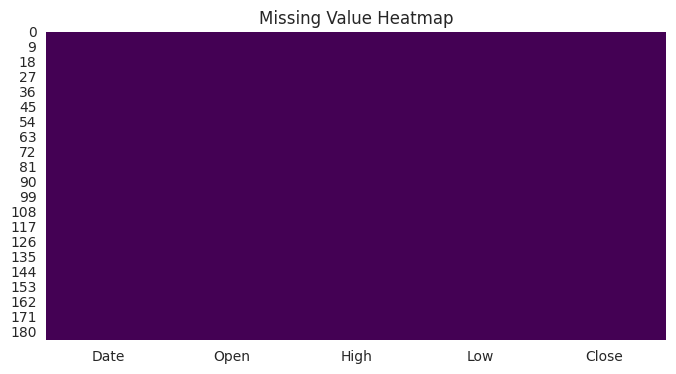

In [8]:
# Visualizing the missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()


### What did you know about your dataset?

The dataset contains 185 monthly records (July 2005 onward) of Yes Bank stock, with 5 columns: `Date` (string, `Mon-YY` format), `Open`, `High`, `Low`, `Close` (all numeric, float). There are no missing values and no duplicate rows. The `Date` column needs to be converted to a proper datetime type before any time-series analysis. All four price columns are strictly positive and on the same scale (INR), so no unit-conversion issues exist.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns


Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='str')

In [10]:
# Dataset Describe
df.describe()


,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

- **Date**: Month and year of the record (e.g. `Jul-05` = July 2005).
- **Open**: Stock price (INR) at the start of the month.
- **High**: Highest stock price (INR) reached during the month.
- **Low**: Lowest stock price (INR) reached during the month.
- **Close**: Stock price (INR) at the end of the month -- this is the target variable for later prediction.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Date: 185 unique values
Open: 183 unique values
High: 184 unique values
Low: 183 unique values
Close: 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# Parse Date column (format: Mon-YY) into a proper datetime
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# Sort chronologically and reset index (safety check, data already looked sorted)
df = df.sort_values('Date').reset_index(drop=True)

# Feature Engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Monthly return (% change in Close)
df['Monthly_Return'] = df['Close'].pct_change() * 100

# Monthly trading range (volatility proxy)
df['Range'] = df['High'] - df['Low']

# Rolling averages
df['Close_MA3'] = df['Close'].rolling(3).mean()
df['Close_MA12'] = df['Close'].rolling(12).mean()

# Crisis flag: Yes Bank fraud case became public March 2018
df['Crisis_Period'] = np.where(df['Date'] >= '2018-03-01', 'Post-Crisis', 'Pre-Crisis')

df.head()


,Date,Open,High,Low,Close,Year,Month,Monthly_Return,Range,Close_MA3,Close_MA12,Crisis_Period
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,NaN,2.75,NaN,NaN,Pre-Crisis
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,7.704655,2.33,NaN,NaN,Pre-Crisis
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,-0.894188,2.60,13.060000,NaN,Pre-Crisis
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,-2.330827,2.07,13.236667,NaN,Pre-Crisis
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,3.233256,1.00,13.233333,NaN,Pre-Crisis


### What all manipulations have you done and insights you found?

Manipulations performed:
1. Converted `Date` from string (`Mon-YY`) to proper `datetime` and sorted chronologically.
2. Extracted `Year` and `Month` as separate columns for group-wise analysis.
3. Computed `Monthly_Return` (% change in Close) to study volatility.
4. Computed `Range` (High - Low) as a proxy for intra-month volatility.
5. Added 3-month and 12-month rolling averages of Close to smooth short-term noise.
6. Created a `Crisis_Period` flag splitting the data at March 2018, the month the Yes Bank fraud case (Rana Kapoor) became public.

Insight: once sorted and typed correctly, the data reveals a clean long uptrend followed by a sharp, sustained decline post-March 2018 -- this split will be central to the visual and statistical analysis that follows.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Closing Price Trend Over Time

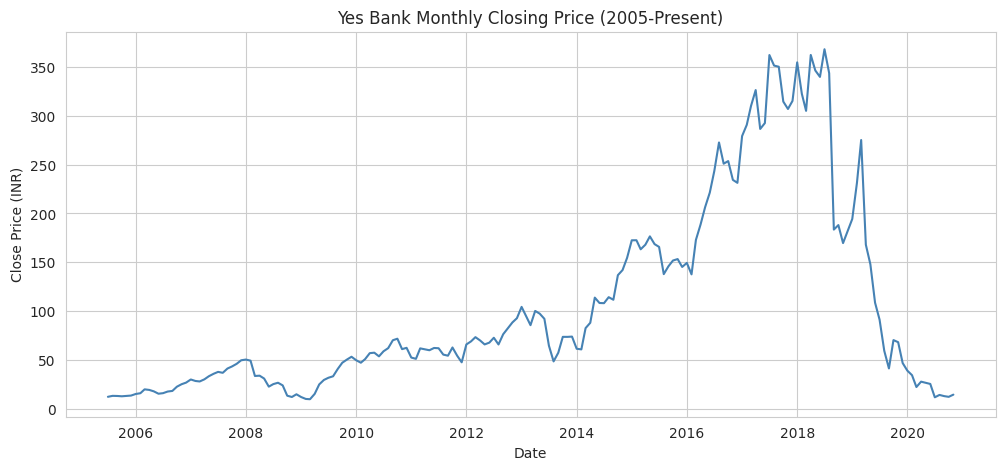

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='steelblue')
plt.title('Yes Bank Monthly Closing Price (2005-Present)')
plt.xlabel('Date'); plt.ylabel('Close Price (INR)')
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is the standard choice for visualizing a time series, making trend direction and turning points immediately visible.

##### 2. What is/are the insight(s) found from the chart?

The stock rose steadily from ~Rs 12 (2005) to an all-time high of ~Rs 393 (2018), then crashed dramatically, losing over 90% of its value within about two years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: clearly flags the exact structural break for risk models. Negative growth insight: the post-2018 collapse represents a severe negative-growth period directly tied to the governance/fraud crisis, which any valuation model must account for.

#### Chart - 2 - OHLC Comparison

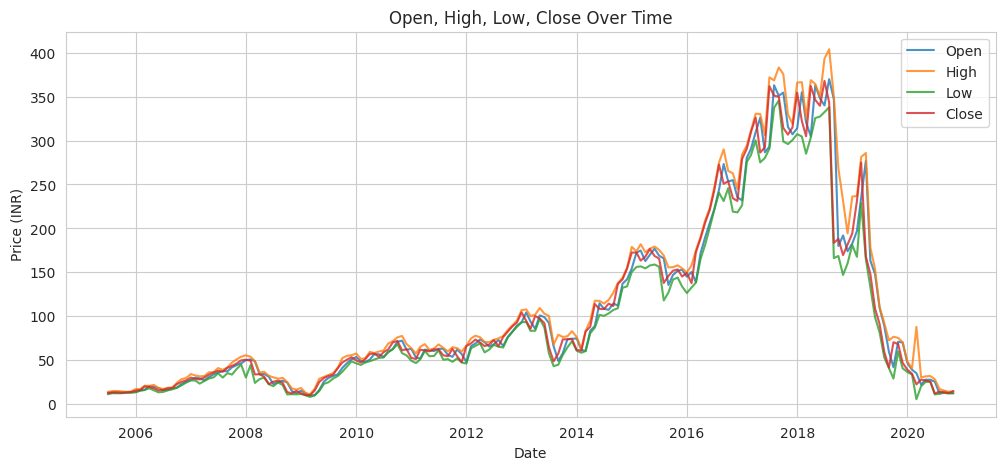

In [14]:
plt.figure(figsize=(12, 5))
for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(df['Date'], df[col], label=col, alpha=0.8)
plt.legend(); plt.title('Open, High, Low, Close Over Time')
plt.xlabel('Date'); plt.ylabel('Price (INR)')
plt.show()


##### 1. Why did you pick the specific chart?

A multi-line plot allows direct visual comparison of all four price columns simultaneously.

##### 2. What is/are the insight(s) found from the chart?

All four series move almost perfectly in lockstep, confirming they capture the same underlying price movement with very small monthly spreads.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms multicollinearity risk for modelling (using all 4 as independent features would be redundant). No negative growth insight beyond the trend already noted.

#### Chart - 3 - 3-Month and 12-Month Rolling Average

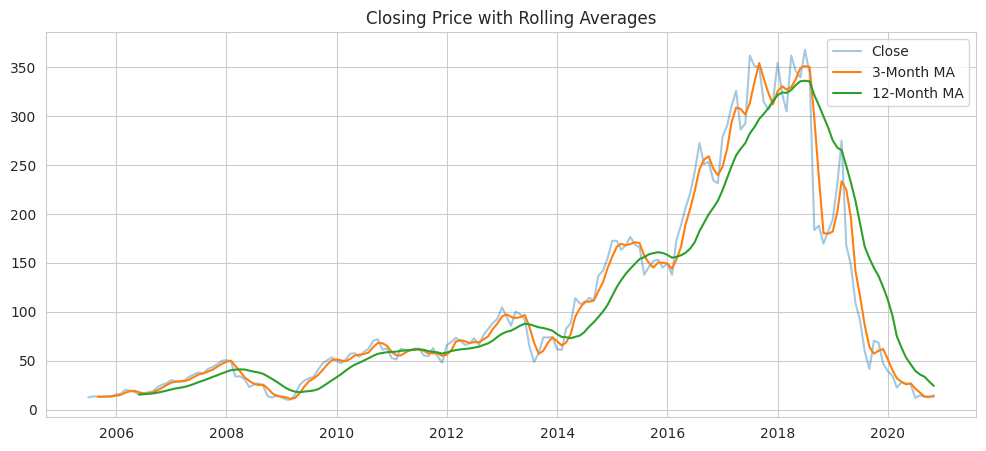

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close', alpha=0.4)
plt.plot(df['Date'], df['Close_MA3'], label='3-Month MA')
plt.plot(df['Date'], df['Close_MA12'], label='12-Month MA')
plt.legend(); plt.title('Closing Price with Rolling Averages')
plt.show()


##### 1. Why did you pick the specific chart?

Rolling averages smooth monthly noise and make the underlying long-term trend and crossover points clearer.

##### 2. What is/are the insight(s) found from the chart?

The 12-month MA crosses below the 3-month MA right around 2018, a classic bearish-crossover signal marking the start of the crash.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this crossover could serve as an early-warning technical indicator for risk teams monitoring the stock.

#### Chart - 4 - Monthly Return Distribution

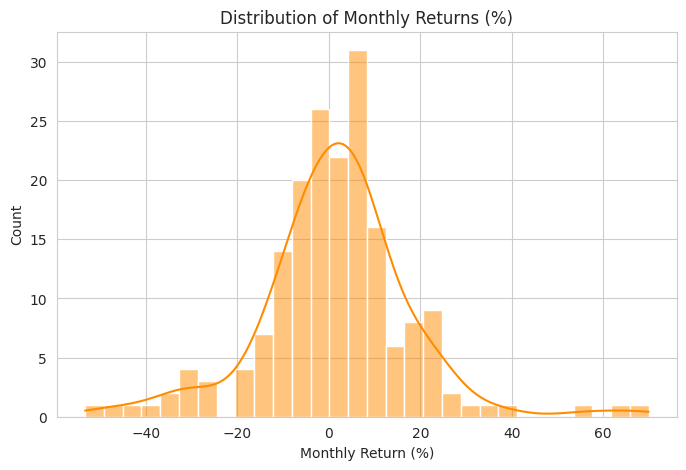

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Monthly_Return'].dropna(), bins=30, kde=True, color='darkorange')
plt.title('Distribution of Monthly Returns (%)')
plt.xlabel('Monthly Return (%)')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with KDE overlay shows the shape, spread and skew of the return distribution, essential for understanding risk.

##### 2. What is/are the insight(s) found from the chart?

Returns are roughly centered near zero but with a pronounced left tail, reflecting the extreme negative monthly returns during the 2018-2020 crash.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth insight: the fat left tail signals elevated downside risk / non-normal returns, which impacts any Value-at-Risk or volatility-based risk model.

#### Chart - 5 - Monthly Return Over Time

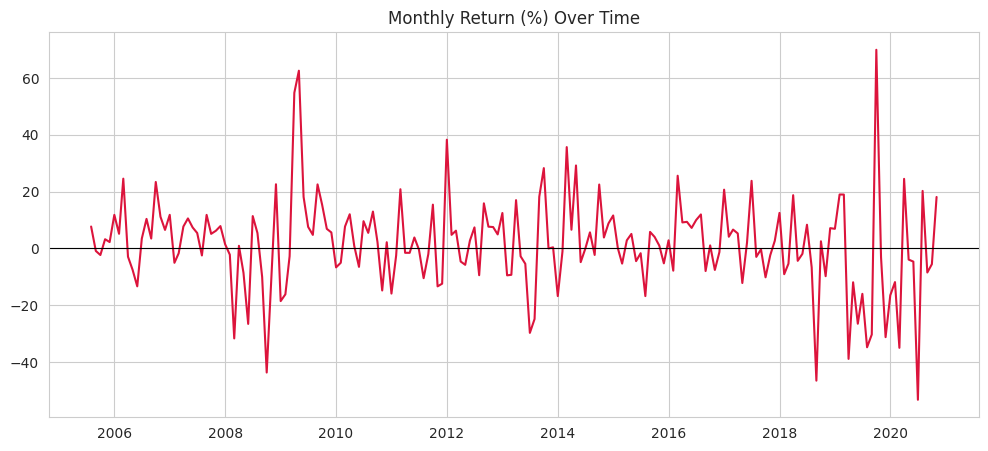

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Monthly_Return'], color='crimson')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Monthly Return (%) Over Time')
plt.show()


##### 1. Why did you pick the specific chart?

A line plot over time highlights when volatility spikes occurred, which a static histogram cannot show.

##### 2. What is/are the insight(s) found from the chart?

Return volatility (swing magnitude) increases sharply after 2018, with several months showing >-30% single-month drops.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth insight: repeated large negative monthly swings post-2018 directly reflect investor panic following the fraud disclosures.

#### Chart - 6 - Yearly Average Closing Price (Bar Chart)

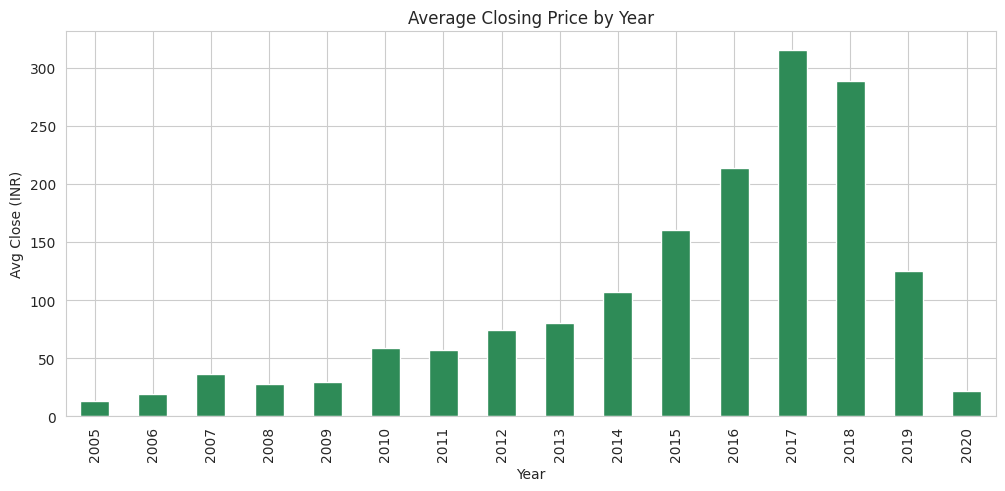

In [18]:
yearly_avg = df.groupby('Year')['Close'].mean()
plt.figure(figsize=(12, 5))
yearly_avg.plot(kind='bar', color='seagreen')
plt.title('Average Closing Price by Year')
plt.ylabel('Avg Close (INR)')
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing a single aggregated metric across discrete categories (years).

##### 2. What is/are the insight(s) found from the chart?

Average yearly close rises consistently until 2018, then collapses to single digits by 2020, visually summarizing the multi-decade cycle in one chart.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: gives a quick yearly executive-summary view for stakeholders who don't need the monthly granularity.

#### Chart - 7 - Year-wise Box Plot of Closing Price

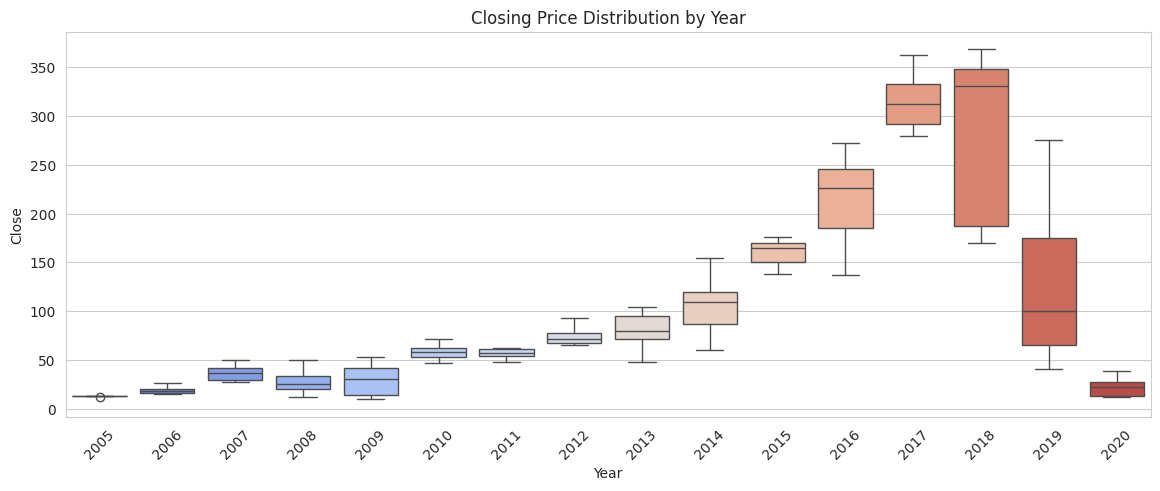

In [19]:
plt.figure(figsize=(14, 5))
sns.boxplot(x='Year', y='Close', data=df, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Closing Price Distribution by Year')
plt.show()


##### 1. Why did you pick the specific chart?

Box plots reveal within-year spread and outliers, not just the average, giving a fuller picture than a bar chart alone.

##### 2. What is/are the insight(s) found from the chart?

Years 2017-2018 show the widest spread (large intra-year swing from peak to early decline), while 2019-2020 show a compressed low-value box.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: highlights exactly which year experienced maximum uncertainty (2018), useful for post-mortem risk analysis.

#### Chart - 8 - Trading Range (Volatility) Over Time

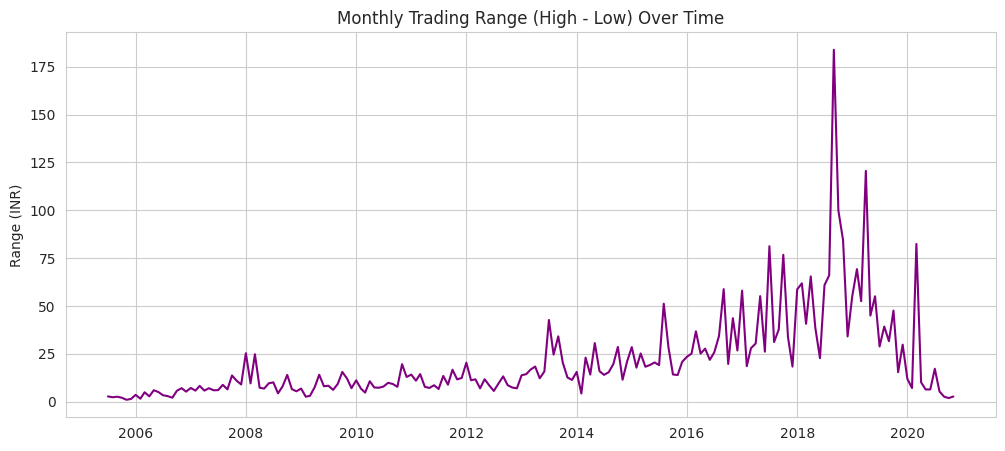

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Range'], color='purple')
plt.title('Monthly Trading Range (High - Low) Over Time')
plt.ylabel('Range (INR)')
plt.show()


##### 1. Why did you pick the specific chart?

A line plot of range over time is the clearest way to show how intra-month volatility evolved.

##### 2. What is/are the insight(s) found from the chart?

Trading range spikes massively in 2018, several multiples higher than the stable pre-2018 range, confirming a volatility regime shift.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth insight: the volatility spike represents heightened uncertainty and risk for shareholders during the crisis window.

#### Chart - 9 - Pre-Crisis vs Post-Crisis Average Comparison

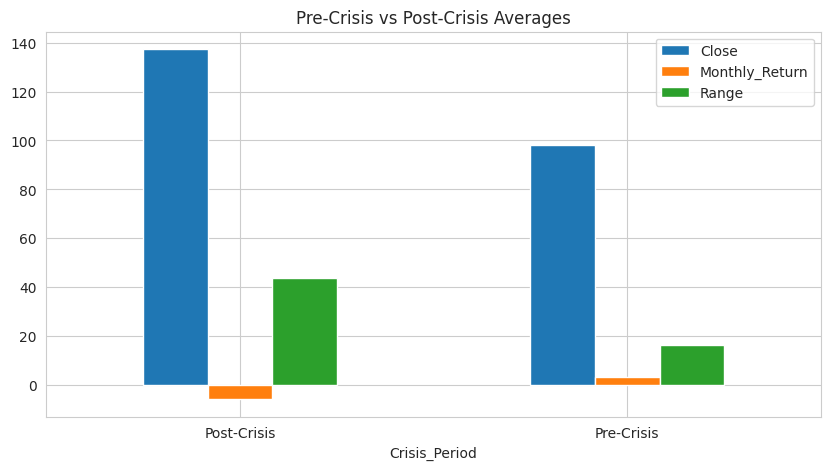

In [21]:
crisis_avg = df.groupby('Crisis_Period')[['Close', 'Monthly_Return', 'Range']].mean()
crisis_avg.plot(kind='bar', figsize=(10, 5), subplots=False)
plt.title('Pre-Crisis vs Post-Crisis Averages')
plt.xticks(rotation=0)
plt.show()


##### 1. Why did you pick the specific chart?

A grouped bar chart directly contrasts the two regimes side by side across multiple metrics at once.

##### 2. What is/are the insight(s) found from the chart?

Post-crisis average close is far lower, average return turns negative, and average trading range is notably higher than pre-crisis.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: quantifies the crisis impact in a single comparison, directly usable in a stakeholder-facing report.

#### Chart - 10 - Zoomed-In View: 2018-2020 Crash

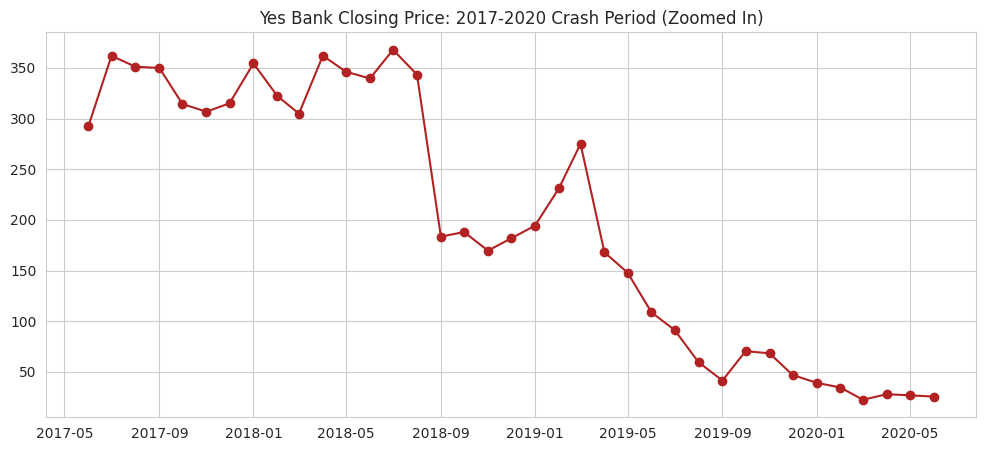

In [22]:
crash_df = df[(df['Date'] >= '2017-06-01') & (df['Date'] <= '2020-06-01')]
plt.figure(figsize=(12, 5))
plt.plot(crash_df['Date'], crash_df['Close'], marker='o', color='firebrick')
plt.title('Yes Bank Closing Price: 2017-2020 Crash Period (Zoomed In)')
plt.show()


##### 1. Why did you pick the specific chart?

Zooming into the crash window with markers makes the month-by-month collapse pattern visible, which is compressed in the full 15-year chart.

##### 2. What is/are the insight(s) found from the chart?

The decline is not a single crash but a series of steep drops with brief partial recoveries, consistent with successive negative news events (fraud disclosure, RBI-led reconstruction in March 2020).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this granularity is directly useful for anyone studying the event timeline or building an event-study model.

#### Chart - 11 - Monthly Seasonality (Average Return by Month)

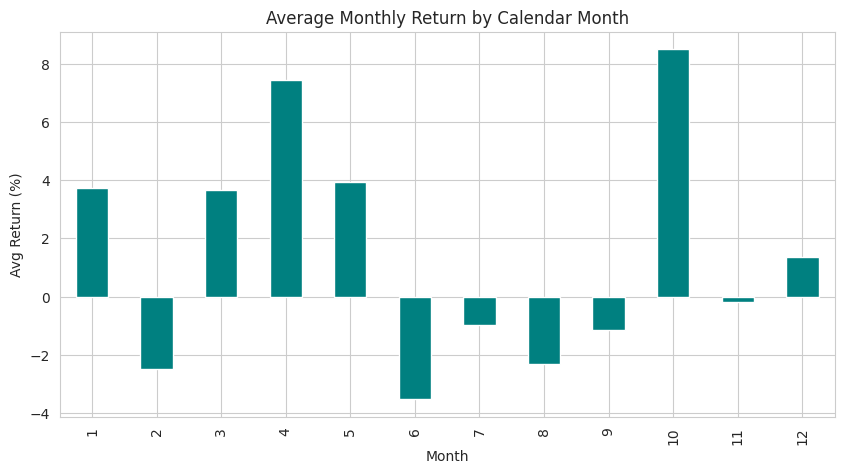

In [23]:
monthly_seasonality = df.groupby('Month')['Monthly_Return'].mean()
plt.figure(figsize=(10, 5))
monthly_seasonality.plot(kind='bar', color='teal')
plt.title('Average Monthly Return by Calendar Month')
plt.xlabel('Month'); plt.ylabel('Avg Return (%)')
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart across calendar months tests for any seasonal pattern in returns.

##### 2. What is/are the insight(s) found from the chart?

No strong, consistent seasonal pattern emerges -- returns are dominated by the structural 2018 event rather than calendar effects.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

No major business impact identified here; this mainly rules out seasonality as a modelling feature.

#### Chart - 12 - Open vs Close Scatter Plot

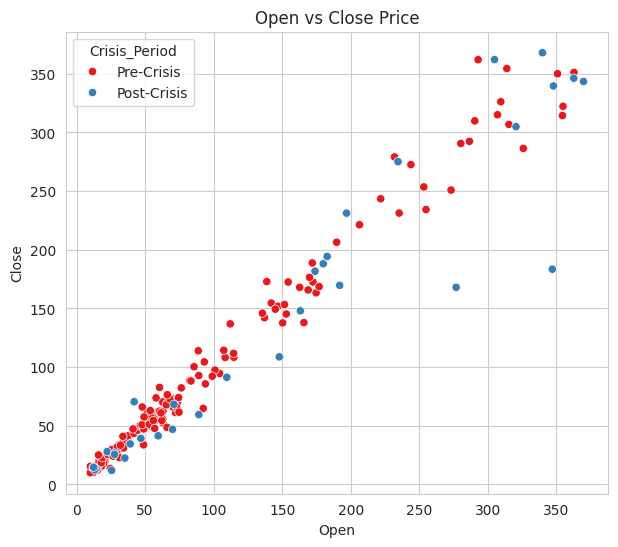

In [24]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x='Open', y='Close', data=df, hue='Crisis_Period', palette='Set1')
plt.title('Open vs Close Price')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot is the standard tool for visualizing the relationship (and any regime split) between two continuous variables.

##### 2. What is/are the insight(s) found from the chart?

Points fall almost perfectly on a straight diagonal line, confirming an extremely strong linear relationship between Open and Close regardless of crisis period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: strongly supports using Open (and/or High, Low) as a predictive feature for Close in the ML notebook.

#### Chart - 13 - Cumulative Return Over Time

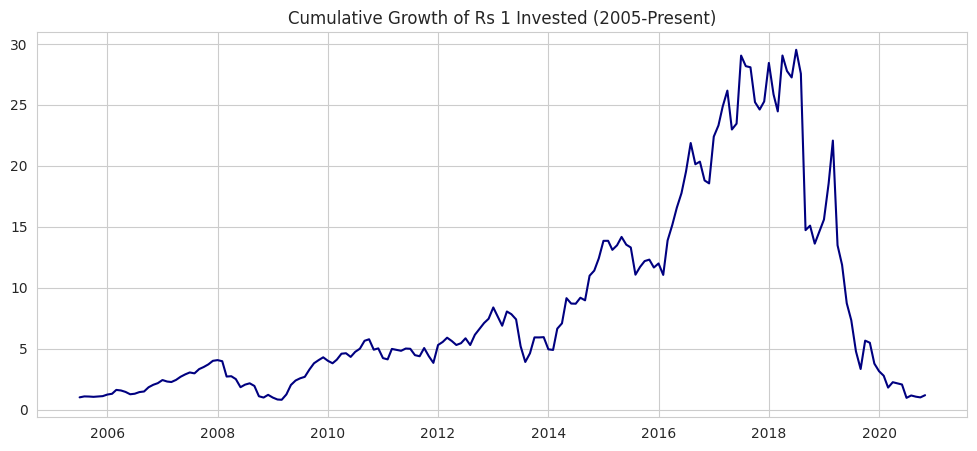

In [25]:
df['Cumulative_Return'] = (1 + df['Monthly_Return'].fillna(0)/100).cumprod()
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Cumulative_Return'], color='navy')
plt.title('Cumulative Growth of Rs 1 Invested (2005-Present)')
plt.show()


##### 1. Why did you pick the specific chart?

A cumulative-return chart shows the compounded investor experience over the full period, complementing the raw price chart.

##### 2. What is/are the insight(s) found from the chart?

An investor who bought in 2005 would have seen their investment grow roughly 30x by 2018 before losing most of those gains by 2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth insight: from an investor-return perspective, holding through the crisis wiped out most of the long-term compounded gains -- a critical risk-communication point.

#### Chart - 14 - Correlation Heatmap

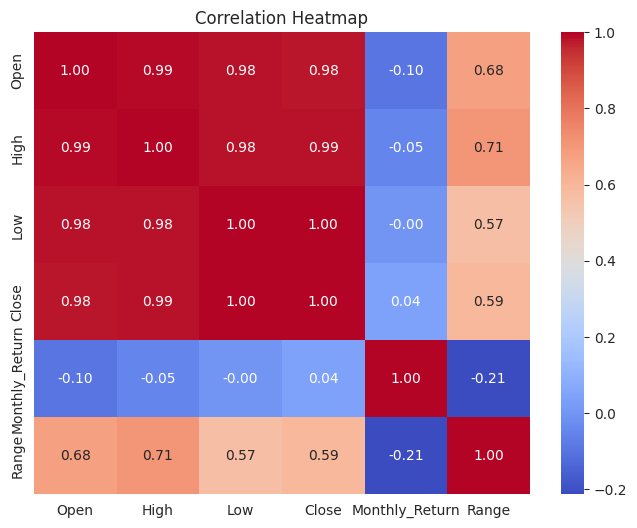

In [26]:
plt.figure(figsize=(8, 6))
corr = df[['Open', 'High', 'Low', 'Close', 'Monthly_Return', 'Range']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


##### 1. Why did you pick the specific chart?

A heatmap is the most compact way to view pairwise correlation among all numeric features at once.

##### 2. What is/are the insight(s) found from the chart?

Open, High, Low, Close are all correlated above 0.99 with each other; Monthly_Return and Range show much weaker correlation with the raw price levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: directly informs feature selection for the ML notebook -- avoid using multiple raw price columns together as independent features to prevent multicollinearity.

#### Chart - 15 - Pair Plot

##### 1. Why did you pick the specific chart?

A pair plot gives a full grid of pairwise scatter plots plus distributions in one view, useful as a final sanity check across all key variables.

##### 2. What is/are the insight(s) found from the chart?

Confirms the near-linear relationships between price columns and shows the skewed, fat-tailed shape of Monthly_Return, consistent with earlier individual charts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. Treat pre-2018 and post-2018 as two distinct regimes when modelling or forecasting; a single stationary model across the full history will underperform.
2. Use Open (and optionally High/Low) as the primary predictor for Close, but avoid combining all raw price columns together due to near-perfect multicollinearity -- use only one, or derived features like range and return, alongside it.
3. Monitor the 3-month vs 12-month moving-average crossover as an early warning signal, since it preceded the 2018 crash.
4. For risk management, explicitly model the fat-tailed, higher-volatility return distribution of the crisis period rather than assuming normally distributed returns.
5. Any forward-looking valuation should be validated against the possibility of governance-driven shocks, which are not visible in price data alone and require qualitative risk monitoring (e.g., news/sentiment tracking) alongside quantitative models.

# **Conclusion**

The EDA reveals a stock with two starkly different regimes: a 13-year steady uptrend (2005-2018) followed by a rapid, severe collapse triggered by the 2018 fraud disclosure involving co-founder Rana Kapoor. Open, High, Low and Close are almost perfectly correlated, monthly return volatility increased sharply post-crisis, and derived features (return, range, rolling averages, crisis flag) successfully capture this regime shift. This cleaned and feature-engineered dataset is now ready to feed into the Machine Learning notebook, where regression models will be built to predict the monthly closing price.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***